In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")

payments = pd.read_csv("olist_order_payments_dataset.csv")

customers = pd.read_csv("olist_customers_dataset.csv")

items = pd.read_csv("olist_order_items_dataset.csv")

products = pd.read_csv("olist_products_dataset.csv")

In [3]:
print(orders.shape)
print(payments.shape)
print(customers.shape)
print(items.shape)
print(products.shape)

(99441, 8)
(103886, 5)
(99441, 5)
(112650, 7)
(32951, 9)


In [4]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [5]:
orders.info()



<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
orders.duplicated().sum()


np.int64(0)

In [8]:
orders = orders.drop_duplicates()


In [9]:
date_cols = [

'order_purchase_timestamp',

'order_delivered_customer_date',

'order_estimated_delivery_date'

]


for col in date_cols:

    orders[col] = pd.to_datetime(orders[col])

In [10]:
orders['delivery_days']=(
orders['order_delivered_customer_date']
-
orders['order_purchase_timestamp']
).dt.days

In [11]:
orders['delay_days']=(
orders['order_delivered_customer_date']
-
orders['order_estimated_delivery_date']
).dt.days

In [12]:
orders['month']=orders[
'order_purchase_timestamp'
].dt.month

In [13]:
orders['weekday']=orders[
'order_purchase_timestamp'
].dt.day_name()

In [14]:
df=orders.merge(

customers,

on='customer_id',

how='left'

)

In [15]:
df=df.merge(

payments,

on='order_id',

how='left'

)

In [24]:
df.to_csv('final_merged_df.csv', index=False)

In [16]:
df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,month,weekday,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,10,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,10,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,10,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,7,Tuesday,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,8,Wednesday,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


## Chart 1: Distribution of Delivery Days
Purpose: To understand how many days orders typically take to reach customers.

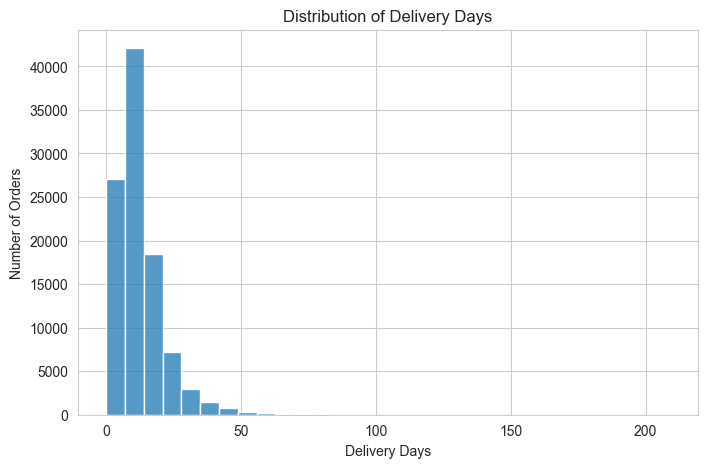

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['delivery_days'], bins=30)

plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.show()

## Chart 2: Delayed vs Not Delayed Orders
Purpose: To identify the proportion of delayed orders.

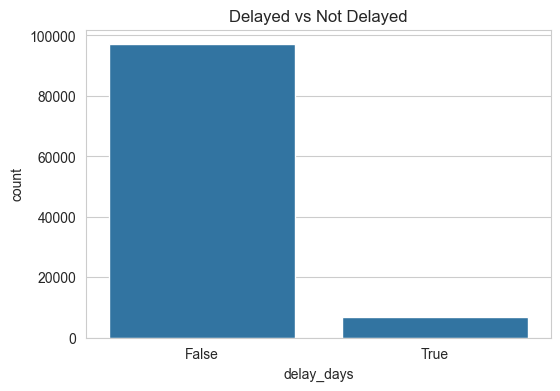

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['delay_days'] > 0)

plt.title("Delayed vs Not Delayed")
plt.show()


## Chart 3: Payment Method Distribution

**Purpose:** To identify the most commonly used payment methods by customers.

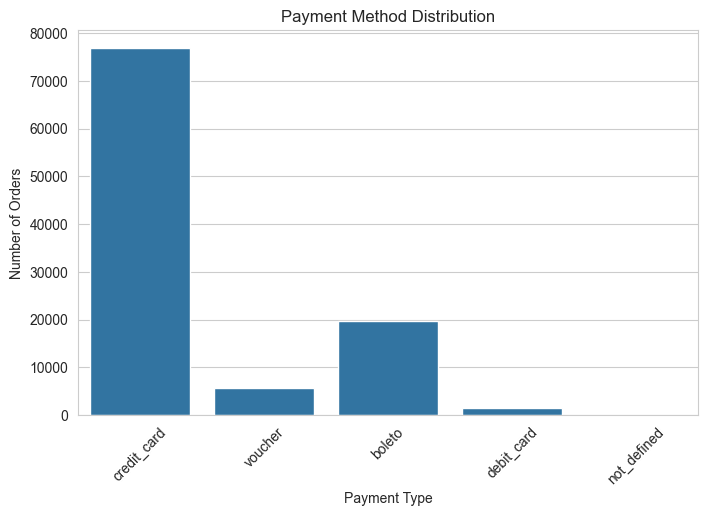

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='payment_type')

plt.title('Payment Method Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.show()

## Chart 4: Monthly Order Trend

**Purpose:** To observe how the number of orders changes over different months.

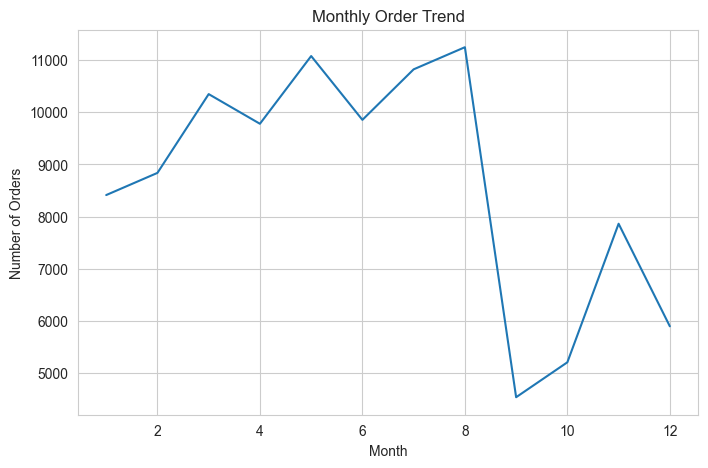

In [21]:
monthly_orders = df.groupby('month').size()

plt.figure(figsize=(8,5))

monthly_orders.plot()

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.show()


## Chart 5: Top 10 Customer States

**Purpose:** To determine which states contribute the highest number of customers.

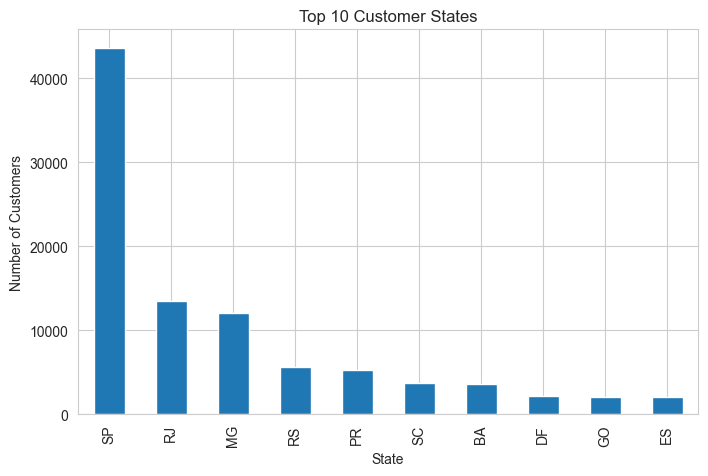

In [22]:
top_states = df['customer_state'].value_counts().head(10)

plt.figure(figsize=(8,5))

top_states.plot(kind='bar')

plt.title('Top 10 Customer States')
plt.xlabel('State')
plt.ylabel('Number of Customers')

plt.show()

## Chart 6: Delay Days by Payment Type

**Purpose:** To compare delivery delays across different payment methods.

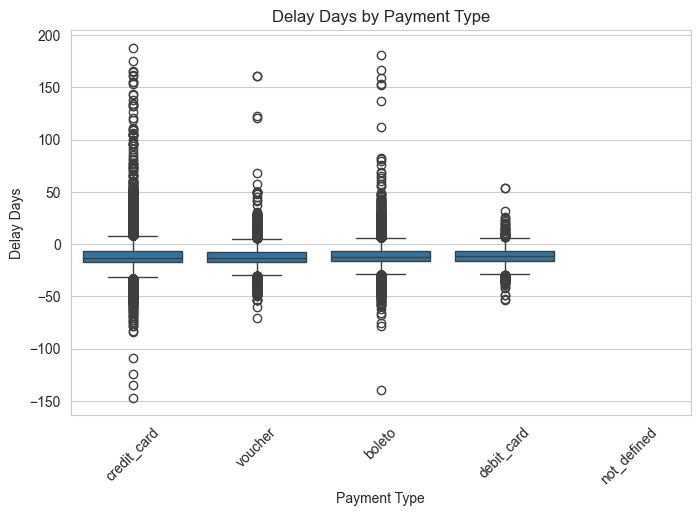

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='payment_type',
    y='delay_days'
)

plt.title('Delay Days by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Delay Days')

plt.xticks(rotation=45)

plt.show()

# EDA Insights

### Insight 1
Most orders are delivered within a limited range of days, indicating a relatively stable delivery process.

### Insight 2
The majority of orders are delivered on time, while only a small percentage experience delays.

### Insight 3
Credit cards are the most commonly used payment method among customers.

### Insight 4
Order volume varies across months, suggesting seasonal purchasing trends.

### Insight 5
Certain customer states contribute significantly more orders than others.